# Time Series Foundation Models — Live Demo

Can we forecast time series **without training a model?** In this notebook we compare three approaches on the classic AirPassengers dataset:

1. **AutoARIMA** (statsforecast) — the traditional approach: fit a statistical model on the data
2. **Chronos** (Amazon) — a foundation model pre-trained on billions of time points, used zero-shot
3. **TimesFM** (Google) — another foundation model, patch-based architecture, also zero-shot

> **Note:** Chronos and TimesFM download model weights from HuggingFace on first run (~75MB and ~800MB respectively). After that, they run entirely offline on your CPU.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
import torch
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 13})

COLORS = {
    'actual': '#2c3e50',
    'train': '#95a5a6',
    'arima': '#e74c3c',
    'chronos': '#3498db',
    'timesfm': '#2ecc71',
}

## The Dataset: AirPassengers

**144 monthly observations** (Jan 1949 – Dec 1960) of international airline passenger numbers (in thousands).

Why this dataset?
- Universally recognized in time series literature
- Clear **upward trend** and strong **multiplicative seasonality** (variance grows as the level increases)
- Small enough to run all models instantly on a laptop CPU

In [18]:
# Load AirPassengers
raw = sm.datasets.get_rdataset('AirPassengers').data

df = pd.DataFrame({
    'unique_id': 'AirPassengers',
    'ds': pd.date_range(start='1949-01', periods=len(raw), freq='MS'),
    'y': raw['value'].values,
})

df.head()

,unique_id,ds,y
0,AirPassengers,1949-01-01,112
1,AirPassengers,1949-02-01,118
2,AirPassengers,1949-03-01,132
3,AirPassengers,1949-04-01,129
4,AirPassengers,1949-05-01,121


### Seasonal Decomposition

Any time series can be broken down into three components:

- **Trend** — the long-term direction (here: passengers growing over the decade)
- **Seasonality** — repeating patterns at fixed intervals (here: summer peaks every 12 months)
- **Residuals** — whatever is left after removing trend and seasonality — the "noise" or unexplained variation

We use **multiplicative** decomposition (Original = Trend x Seasonality x Residual) because the seasonal swings get larger as the overall level rises.

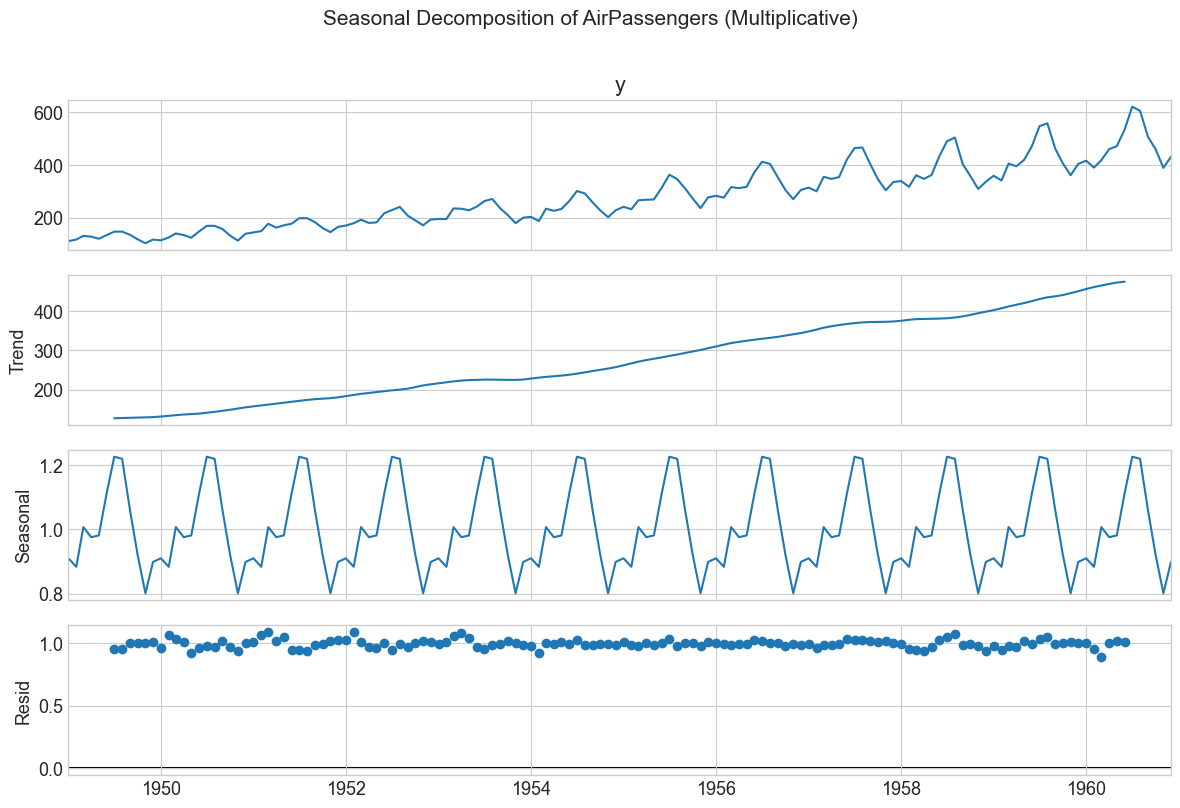

In [19]:
# Seasonal decomposition — multiplicative because variance grows with level
result = seasonal_decompose(df.set_index('ds')['y'], model='multiplicative', period=12)

fig = result.plot()
fig.set_size_inches(12, 8)
fig.suptitle('Seasonal Decomposition of AirPassengers (Multiplicative)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## Train / Test Split

We hold out the **last 24 months** (1959–1960) as our test set. The models get 10 years of history (120 points) and must forecast 2 years ahead.

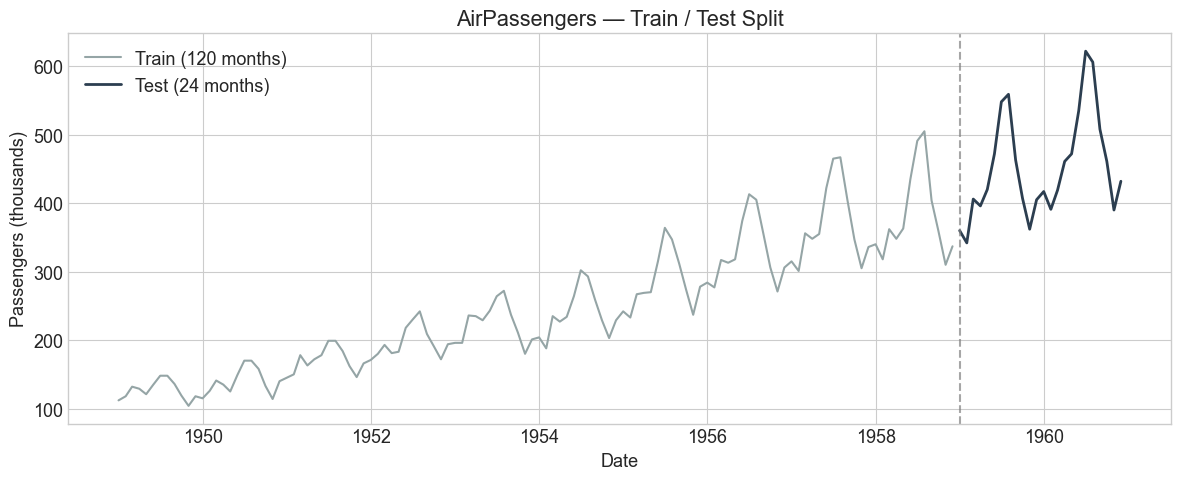

In [20]:
h = 24  # forecast horizon (months)
df_train = df.iloc[:-h]
df_test = df.iloc[-h:]

fig, ax = plt.subplots()
ax.plot(df_train['ds'], df_train['y'], color=COLORS['train'], label='Train (120 months)')
ax.plot(df_test['ds'], df_test['y'], color=COLORS['actual'], linewidth=2, label='Test (24 months)')
ax.axvline(df_test['ds'].iloc[0], color='grey', linestyle='--', alpha=0.7)
ax.set(title='AirPassengers — Train / Test Split', xlabel='Date', ylabel='Passengers (thousands)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Approach 1: AutoARIMA (Traditional)

**ARIMA** (AutoRegressive Integrated Moving Average) is the workhorse of classical time series forecasting. It models a time series as a combination of:
- **AR** (AutoRegressive) — the value depends on its own past values
- **I** (Integrated) — differencing to remove trends. Instead of modeling raw values like `[100, 120, 150]`, we model the changes `[+20, +30]`. This makes the data *stationary* (roughly constant mean and variance over time), which ARIMA requires.
- **MA** (Moving Average) — the value depends on past forecast errors

**AutoARIMA** automates the hard part: it searches over different combinations of parameters (p, d, q) and their seasonal counterparts (P, D, Q) to find the best fit using information criteria.

We still need to provide **domain knowledge**: `season_length=12` tells the model "this data has a yearly cycle" (12 months). The model is then **fitted on the 120 training data points** (10 years of monthly observations) to forecast the next 24 months.

**Important:** AirPassengers has **multiplicative seasonality** (the seasonal swings grow with the level). ARIMA assumes additive structure, so we **log-transform** the data first — this turns multiplicative patterns into additive ones. We then exponentiate the forecast back to the original scale. This is standard practice.

The shaded area in the plot below is the **90% confidence interval** — the model is 90% confident the true value falls within this band. Wider bands = more uncertainty.

In [21]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

# Log-transform to handle multiplicative seasonality
df_train_log = df_train.copy()
df_train_log['y'] = np.log(df_train_log['y'])

sf = StatsForecast(models=[AutoARIMA(season_length=12)], freq='MS')
arima_fc = sf.forecast(df=df_train_log, h=h, level=[90])

# Inverse transform (exponentiate) back to original scale
arima_fc['AutoARIMA'] = np.exp(arima_fc['AutoARIMA'])
arima_fc['AutoARIMA-lo-90'] = np.exp(arima_fc['AutoARIMA-lo-90'])
arima_fc['AutoARIMA-hi-90'] = np.exp(arima_fc['AutoARIMA-hi-90'])

arima_fc.head()

,unique_id,ds,AutoARIMA,AutoARIMA-lo-90,AutoARIMA-hi-90
0,AirPassengers,1959-01-01,348.429087,327.436307,370.767768
1,AirPassengers,1959-02-01,331.934887,307.881552,357.867395
2,AirPassengers,1959-03-01,383.800259,352.050973,418.412815
3,AirPassengers,1959-04-01,373.377626,339.135269,411.077421
4,AirPassengers,1959-05-01,383.328722,345.079457,425.817607


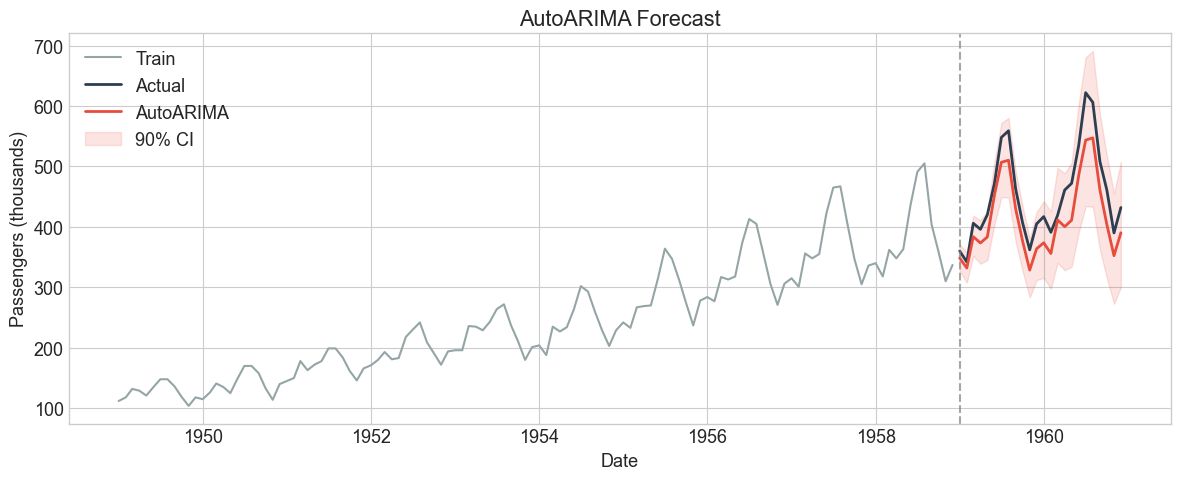

In [22]:
fig, ax = plt.subplots()
ax.plot(df_train['ds'], df_train['y'], color=COLORS['train'], label='Train')
ax.plot(df_test['ds'], df_test['y'], color=COLORS['actual'], linewidth=2, label='Actual')
ax.plot(arima_fc['ds'], arima_fc['AutoARIMA'], color=COLORS['arima'], linewidth=2, label='AutoARIMA')
ax.fill_between(arima_fc['ds'], arima_fc['AutoARIMA-lo-90'], arima_fc['AutoARIMA-hi-90'],
                color=COLORS['arima'], alpha=0.15, label='90% CI')
ax.axvline(df_test['ds'].iloc[0], color='grey', linestyle='--', alpha=0.7)
ax.set(title='AutoARIMA Forecast', xlabel='Date', ylabel='Passengers (thousands)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Approach 2: Chronos — Zero-Shot Foundation Model

**Paradigm shift.** Chronos is a foundation model by Amazon, pre-trained on **billions of time points** from diverse domains (energy, retail, weather, finance...). It has **never seen AirPassengers** during training.

**How it works — tokenization (turning numbers into "words"):**

Imagine you have temperature readings: `[18.3, 19.1, 22.7, 21.5]`. Chronos rounds each value into a "bin" — like saying *18.3 is bin #42, 19.1 is bin #44, 22.7 is bin #55, 21.5 is bin #51*. Now the time series is a sequence of integers `[42, 44, 55, 51]` — just like a sentence is a sequence of words. A language model (T5) then predicts the next "words": *after 42, 44, 55, 51 the next tokens are probably 48, 53...* and those bins are converted back to numbers.

No hyperparameter tuning. No specifying seasonality. No fitting. Just pass the data and get a forecast.

In [23]:
from chronos import ChronosPipeline

pipeline = ChronosPipeline.from_pretrained("amazon/chronos-t5-small", device_map="cpu")

context = torch.tensor(df_train['y'].values, dtype=torch.float32)
quantiles, mean = pipeline.predict_quantiles(
    context.unsqueeze(0),
    prediction_length=h,
    quantile_levels=[0.05, 0.5, 0.95],
)

chronos_mean = mean.squeeze().numpy()
chronos_lo = quantiles.squeeze()[:, 0].numpy()  # 5th percentile
chronos_hi = quantiles.squeeze()[:, 2].numpy()  # 95th percentile

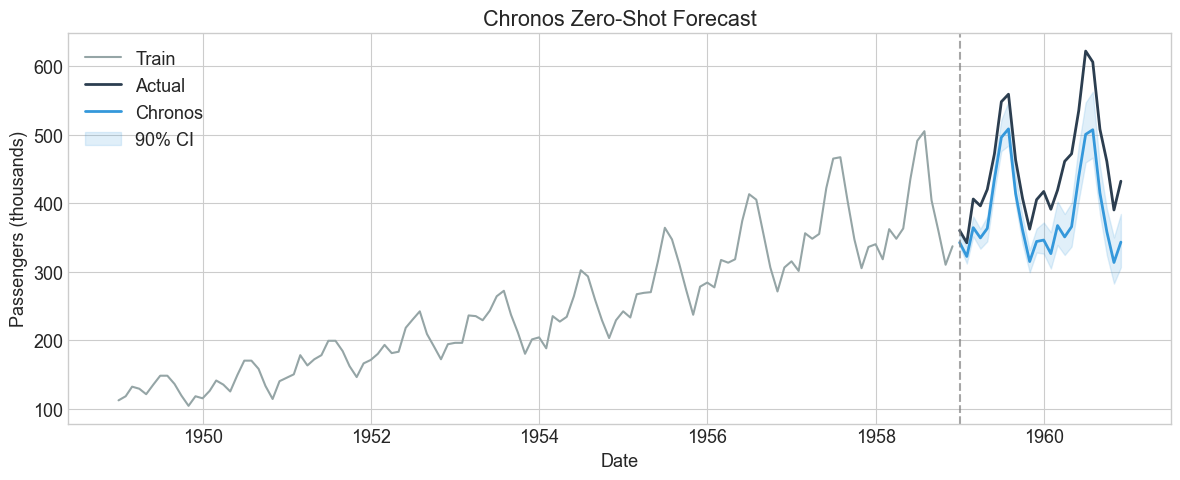

In [24]:
fig, ax = plt.subplots()
ax.plot(df_train['ds'], df_train['y'], color=COLORS['train'], label='Train')
ax.plot(df_test['ds'], df_test['y'], color=COLORS['actual'], linewidth=2, label='Actual')
ax.plot(df_test['ds'], chronos_mean, color=COLORS['chronos'], linewidth=2, label='Chronos')
ax.fill_between(df_test['ds'], chronos_lo, chronos_hi,
                color=COLORS['chronos'], alpha=0.15, label='90% CI')
ax.axvline(df_test['ds'].iloc[0], color='grey', linestyle='--', alpha=0.7)
ax.set(title='Chronos Zero-Shot Forecast', xlabel='Date', ylabel='Passengers (thousands)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Approach 3: TimesFM — Zero-Shot Foundation Model

Google's **TimesFM** uses a different strategy: **patching** (grouping values into chunks).

**How it works — patching (reading in chunks, not letter by letter):**

Instead of looking at values one by one, TimesFM groups them into chunks of 32. Think of reading a book: instead of letter by letter, you read word by word. TimesFM takes 32 consecutive values as one "patch" — a snapshot of what happened in that window. The transformer then looks at all patches and predicts the next patch of values. It sees the big picture, but loses some fine detail — which is why its forecasts tend to be smoother than Chronos.

Also zero-shot, also no training. Different architecture, same promise.

In [25]:
from timesfm import TimesFM_2p5_200M_torch, ForecastConfig

tfm = TimesFM_2p5_200M_torch(torch_compile=False)
tfm.compile(ForecastConfig(max_context=512, max_horizon=128))

mean_fc, quantile_fc = tfm.forecast(horizon=h, inputs=[df_train['y'].values.astype(np.float32)])

timesfm_mean = mean_fc.squeeze()[:h]
timesfm_lo = quantile_fc.squeeze()[:h, 0]    # 0.1 quantile
timesfm_hi = quantile_fc.squeeze()[:h, -1]   # 0.9 quantile

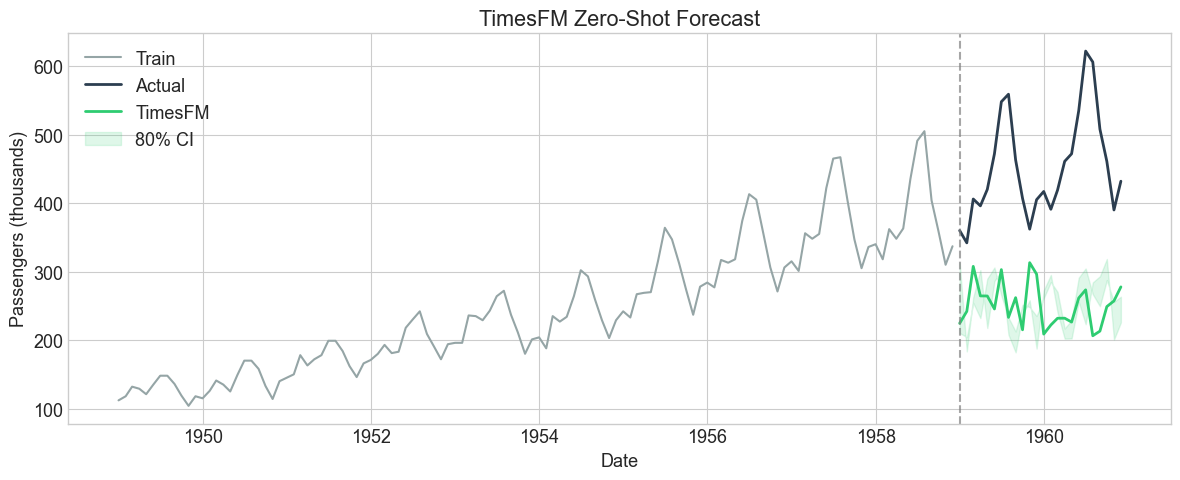

In [26]:
fig, ax = plt.subplots()
ax.plot(df_train['ds'], df_train['y'], color=COLORS['train'], label='Train')
ax.plot(df_test['ds'], df_test['y'], color=COLORS['actual'], linewidth=2, label='Actual')
ax.plot(df_test['ds'], timesfm_mean, color=COLORS['timesfm'], linewidth=2, label='TimesFM')
ax.fill_between(df_test['ds'], timesfm_lo, timesfm_hi,
                color=COLORS['timesfm'], alpha=0.15, label='80% CI')
ax.axvline(df_test['ds'].iloc[0], color='grey', linestyle='--', alpha=0.7)
ax.set(title='TimesFM Zero-Shot Forecast', xlabel='Date', ylabel='Passengers (thousands)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Head-to-Head Comparison

All three forecasts on the same plot, plus error metrics.

**How to read the metrics:**
- **MAE** (Mean Absolute Error) — average absolute difference between predicted and actual values. In our case, it's in thousands of passengers. *"On average, the forecast is off by X thousand passengers."*
- **RMSE** (Root Mean Squared Error) — like MAE but penalizes large errors more heavily. Same units. Lower is better.
- **MAPE** (Mean Absolute Percentage Error) — the error as a percentage. Easy to interpret: a MAPE of 5% means the forecast is off by 5% on average.

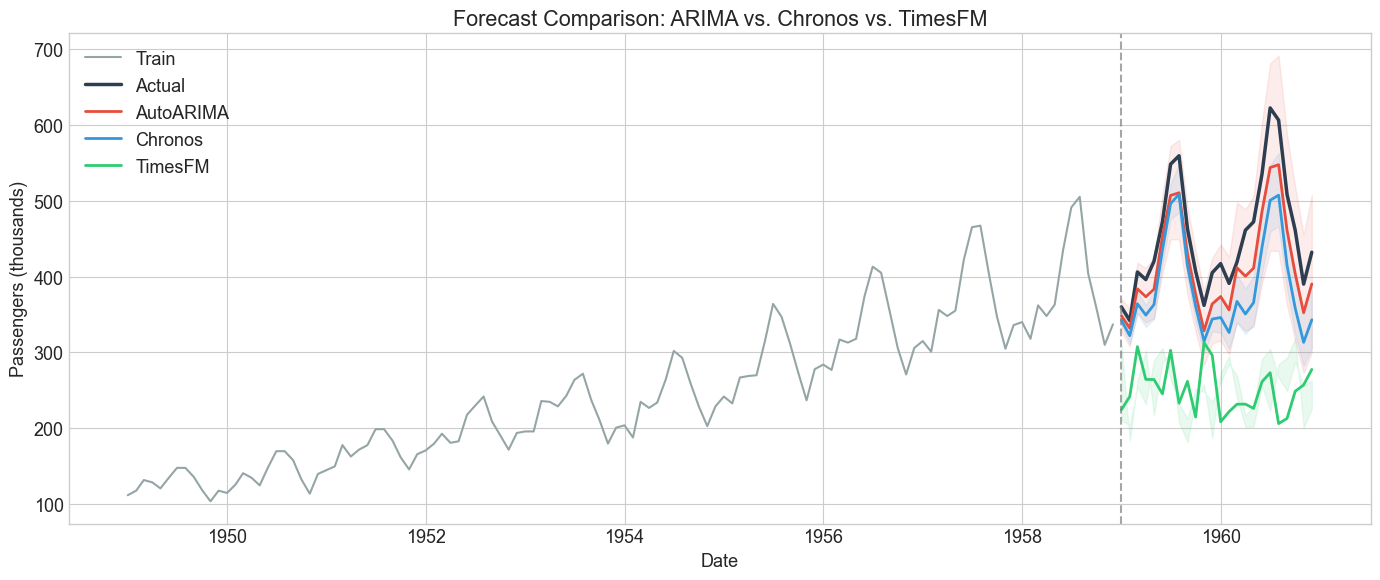

In [27]:
fig, ax = plt.subplots(figsize=(14, 6))

# Training data
ax.plot(df_train['ds'], df_train['y'], color=COLORS['train'], label='Train')
# Actual test data
ax.plot(df_test['ds'], df_test['y'], color=COLORS['actual'], linewidth=2.5, label='Actual')

# ARIMA
ax.plot(arima_fc['ds'], arima_fc['AutoARIMA'], color=COLORS['arima'], linewidth=2, label='AutoARIMA')
ax.fill_between(arima_fc['ds'], arima_fc['AutoARIMA-lo-90'], arima_fc['AutoARIMA-hi-90'],
                color=COLORS['arima'], alpha=0.1)

# Chronos
ax.plot(df_test['ds'], chronos_mean, color=COLORS['chronos'], linewidth=2, label='Chronos')
ax.fill_between(df_test['ds'], chronos_lo, chronos_hi, color=COLORS['chronos'], alpha=0.1)

# TimesFM
ax.plot(df_test['ds'], timesfm_mean, color=COLORS['timesfm'], linewidth=2, label='TimesFM')
ax.fill_between(df_test['ds'], timesfm_lo, timesfm_hi, color=COLORS['timesfm'], alpha=0.1)

ax.axvline(df_test['ds'].iloc[0], color='grey', linestyle='--', alpha=0.7)
ax.set(title='Forecast Comparison: ARIMA vs. Chronos vs. TimesFM', xlabel='Date', ylabel='Passengers (thousands)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [28]:
actual = df_test['y'].values

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

metrics = pd.DataFrame({
    'Model': ['AutoARIMA', 'Chronos (zero-shot)', 'TimesFM (zero-shot)'],
    'MAE': [
        mae(actual, arima_fc['AutoARIMA'].values),
        mae(actual, chronos_mean),
        mae(actual, timesfm_mean),
    ],
    'RMSE': [
        rmse(actual, arima_fc['AutoARIMA'].values),
        rmse(actual, chronos_mean),
        rmse(actual, timesfm_mean),
    ],
    'MAPE (%)': [
        mape(actual, arima_fc['AutoARIMA'].values),
        mape(actual, chronos_mean),
        mape(actual, timesfm_mean),
    ],
}).set_index('Model').round(2)

metrics

,MAE,RMSE,MAPE (%)
Model,,,
AutoARIMA,38.63,42.35,8.33
Chronos (zero-shot),67.05,72.84,14.59
TimesFM (zero-shot),201.00,217.73,42.91


---
## Can It Generalize? A Harder Problem

AirPassengers is clean and well-behaved. Let's try something messier: **ETTh1** — hourly oil temperature readings from an electricity transformer in China.

- **14,400 hourly observations** (Jul 2016 – Feb 2018)
- Noisier, less regular seasonality, real-world sensor data
- We'll use the last 2,000 hours as context and forecast **1 week ahead (168 hours)**

Same three models, no changes. Can the foundation models handle this without retraining?

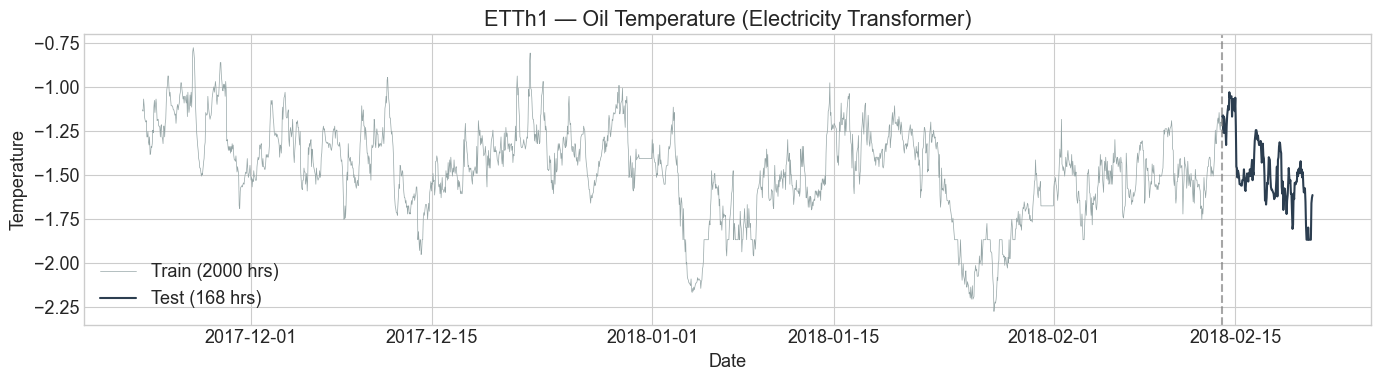

In [29]:
from datasetsforecast.long_horizon import LongHorizon

df_ett, *_ = LongHorizon.load(directory='./data', group='ETTh1')
df_ett['ds'] = pd.to_datetime(df_ett['ds'])

# Use the last 2000 + 168 hours to keep it fast
h2 = 168  # 1 week
tail = df_ett.tail(2000 + h2).copy().reset_index(drop=True)
ett_train = tail.iloc[:-h2]
ett_test = tail.iloc[-h2:]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ett_train['ds'], ett_train['y'], color=COLORS['train'], linewidth=0.5, label='Train (2000 hrs)')
ax.plot(ett_test['ds'], ett_test['y'], color=COLORS['actual'], linewidth=1.5, label='Test (168 hrs)')
ax.axvline(ett_test['ds'].iloc[0], color='grey', linestyle='--', alpha=0.7)
ax.set(title='ETTh1 — Oil Temperature (Electricity Transformer)', xlabel='Date', ylabel='Temperature')
ax.legend()
plt.tight_layout()
plt.show()

In [30]:
# --- ARIMA ---
sf2 = StatsForecast(models=[AutoARIMA(season_length=24)], freq='h')
arima_fc2 = sf2.forecast(df=ett_train, h=h2)

# --- Chronos ---
# Note: Chronos warns that prediction_length > 64 may degrade quality — good to know!
context2 = torch.tensor(ett_train['y'].values, dtype=torch.float32)
q2, m2 = pipeline.predict_quantiles(context2.unsqueeze(0), prediction_length=h2, quantile_levels=[0.05, 0.5, 0.95])
chronos_mean2 = m2.squeeze().numpy()

# --- TimesFM (re-compile with longer horizon) ---
tfm.compile(ForecastConfig(max_context=512, max_horizon=h2))
mean_fc2, _ = tfm.forecast(horizon=h2, inputs=[ett_train['y'].values.astype(np.float32)])
timesfm_mean2 = mean_fc2.squeeze()[:h2]

INFO:root:When compiling, max horizon needs to be multiple of the output patch size 128. Using max horizon = 256 instead.


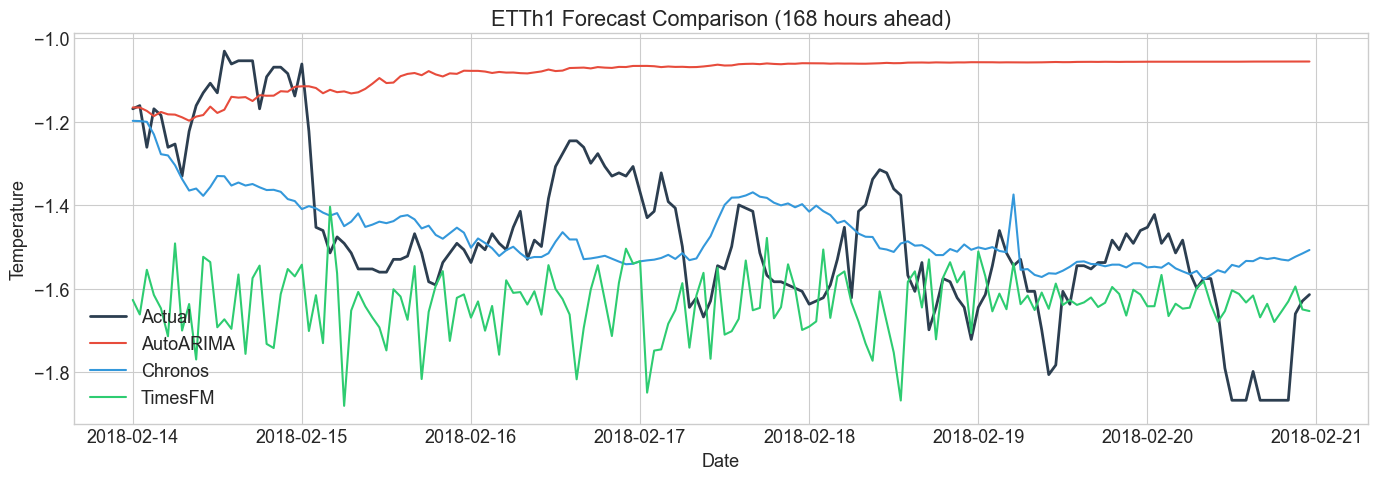

In [31]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ett_test['ds'], ett_test['y'].values, color=COLORS['actual'], linewidth=2, label='Actual')
ax.plot(arima_fc2['ds'], arima_fc2['AutoARIMA'].values, color=COLORS['arima'], linewidth=1.5, label='AutoARIMA')
ax.plot(ett_test['ds'], chronos_mean2, color=COLORS['chronos'], linewidth=1.5, label='Chronos')
ax.plot(ett_test['ds'], timesfm_mean2, color=COLORS['timesfm'], linewidth=1.5, label='TimesFM')
ax.set(title='ETTh1 Forecast Comparison (168 hours ahead)', xlabel='Date', ylabel='Temperature')
ax.legend()
plt.tight_layout()
plt.show()

### What do we see?

This is a **much harder problem** than AirPassengers — and the results tell a clear story:

- **AutoARIMA** (red) goes flat almost immediately. It locks onto the initial level (~-1.1) and stays there, completely missing the downward drift. ARIMA's linear assumptions can't handle this non-stationary, noisy signal.
- **Chronos** (blue) is the best performer here. It captures the general downward movement and stays in the right ballpark for most of the week. It drifts a bit high by mid-week but recovers. Impressive for a model that has never seen this data.
- **TimesFM** (green) oscillates wildly around -1.6, well below the actual values for most of the period. It seems to have captured the right *volatility* but at the wrong *level* — as if it's forecasting the noise pattern without anchoring to the recent context.

**Key takeaway:** On this noisy real-world data, the differences between models become stark. Chronos clearly outperforms the others — but none are perfect over a full week horizon. This is where **fine-tuning** on domain-specific data or **shorter forecast horizons** would help.

### Caveats (for the skeptics)

- **Data leakage on AirPassengers:** AirPassengers is the most famous time series dataset in existence. We cannot guarantee the foundation models didn't see it (or very similar data) during pre-training. The ETTh1 example is a fairer test.
- **Single test window:** We evaluated one train/test split per dataset. This is illustrative, not a rigorous benchmark. A proper evaluation would use multiple windows or cross-validation.
- **ETTh1 data is pre-normalized** (values are negative), so only MAE/RMSE are meaningful — MAPE would be nonsensical on negative values.
- **Chronos recommends prediction_length <= 64** — we're asking for 168 steps, so its quality degrades. TimesFM was also pushed beyond its comfort zone.

In [32]:
actual2 = ett_test['y'].values

# Note: no MAPE here — ETTh1 data is pre-normalized with negative values, making MAPE meaningless
metrics2 = pd.DataFrame({
    'Model': ['AutoARIMA', 'Chronos (zero-shot)', 'TimesFM (zero-shot)'],
    'MAE': [
        mae(actual2, arima_fc2['AutoARIMA'].values),
        mae(actual2, chronos_mean2),
        mae(actual2, timesfm_mean2),
    ],
    'RMSE': [
        rmse(actual2, arima_fc2['AutoARIMA'].values),
        rmse(actual2, chronos_mean2),
        rmse(actual2, timesfm_mean2),
    ],
}).set_index('Model').round(4)

print("ETTh1 — Oil Temperature (168h forecast)")
metrics2

ETTh1 — Oil Temperature (168h forecast)


,MAE,RMSE
Model,,
AutoARIMA,0.4015,0.4478
Chronos (zero-shot),0.1311,0.1616
TimesFM (zero-shot),0.2070,0.2659


---
## The Punchline: Effort vs. Results

| Approach | Lines of Code | Training Required | Domain Knowledge Needed |
|----------|:---:|:---:|:---:|
| AutoARIMA | ~4 | Yes (fit on data) | `season_length=12` or `24` |
| Chronos | ~3 | **No** (zero-shot) | **None** |
| TimesFM | ~5 | **No** (zero-shot) | **None** |

Across **two very different datasets** — clean monthly airline passengers and noisy hourly sensor data — the foundation models required **no training, no hyperparameter tuning**, and produced competitive forecasts. The same model instances, the same code, no changes.

---
## Why Are These Models So Small?

A question you might have: if these are "foundation models", why do they run on a laptop?

| Model | Parameters |
|-------|----------:|
| Chronos-Tiny | 8M |
| Chronos-Small (used above) | 46M |
| TimesFM 2.0 (used above) | 200M |
| GPT-4 (estimated) | ~1,700,000M |

**Language models** need to encode all human knowledge — vocabulary, grammar, facts, reasoning across millions of topics. That requires trillions of parameters.

**Time series** has a much narrower structure — trends, seasonality, cycles, noise. The patterns are mathematical, not semantic. You don't need to "know" that Paris is in France to forecast airline passengers.

**The complexity of the task determines the model size, not the other way around.**

> These models run on your laptop because time series is a fundamentally simpler problem than language.

---
## What's Next?

- These are **strong baselines**, not silver bullets — on your specific dataset, a well-tuned traditional model might still win
- **Fine-tuning** on domain-specific data can significantly improve foundation model results
- The field is moving fast: Chronos, TimesFM, Moirai, MOMENT all released in 2024
- Worth experimenting with — especially for **rapid prototyping** and **zero-shot forecasting** on new datasets where you have no historical model